In [1]:
!pip install torch torchvision torchaudio -q
!pip install torch-geometric -q
!pip install transformers -q
!pip install scikit-learn networkx matplotlib -q
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [1]:
import re
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import spacy
import torch
import torch.nn as nn
from torch.utils.data import Dataset

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

from transformers import AutoTokenizer, AutoModel, logging as hf_logging
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

hf_logging.set_verbosity_error()

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODEL_NAME = "google-bert/bert-base-multilingual-uncased"

MAX_LEN = 298
BATCH_SIZE_GNN   = 16
MODEL_PATH = f'Sin_graph/best_model.pt'

LABEL_MAP = {0: 'negative', 1: 'positive'}

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
import os

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

In [4]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+\.\S+/\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


train_df = pd.read_parquet("train.parquet").reset_index(drop=True)
val_df = pd.read_parquet("val.parquet").reset_index(drop=True)
test_df = pd.read_parquet("test.parquet").reset_index(drop=True)



In [5]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])

In [6]:
# Собираем уникальные типы связей
all_deps = set()
for text in tqdm(train_df["text"].tolist()): # 1000 примеров хватит для словаря
    doc = nlp(text)
    for token in doc:
        all_deps.add(token.dep_)

dep_to_id = {dep: i for i, dep in enumerate(sorted(list(all_deps)))}
NUM_RELATIONS = len(dep_to_id)
print(f"Найдено типов связей: {NUM_RELATIONS}")

100%|██████████| 100000/100000 [04:32<00:00, 367.27it/s]

Найдено типов связей: 45


In [26]:
def build_graph(text, tokenizer, bert_model):
    
    if text is None or len(text.strip()) == 0:
        x = torch.zeros((1, bert_model.config.hidden_size), device=DEVICE)
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0,), dtype=torch.long)
        return x.float(), edge_index, edge_attr
    doc = nlp(text)
    
    # 1. Токенизируем так, чтобы получить карту соответствия (offset_mapping)
    enc = tokenizer(
        text,
        truncation=True,
        padding=False,
        return_offsets_mapping=True, 
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        out = bert_model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])

    hidden = out.last_hidden_state.squeeze(0)
    offsets = enc["offset_mapping"].squeeze(0).cpu().numpy()
    mask = enc["attention_mask"].squeeze(0).cpu().numpy()
    device = hidden.device
    # 2. Выравнивание: Собираем по одному вектору на каждое слово spaCy
    word_embeddings = []
    for token in doc:
        start, end = token.idx, token.idx + len(token.text)
        
        subtoken_indices = []
        for i, (s, e) in enumerate(offsets):
            if mask[i] == 0:
                continue
            # Если подслово пересекается с границами слова spaCy
            if not (e <= start or s >= end):
                subtoken_indices.append(i)
        
        if len(subtoken_indices) > 0:
            # Усредняем векторы всех подслов этого слова
            word_vec = hidden[subtoken_indices].mean(dim=0)
        else:
            # На случай ошибки (пустой вектор) — берем нулевой
            word_vec = torch.zeros(hidden.size(-1), device=device)
            
        word_embeddings.append(word_vec)

    # Теперь x — это тензор, где индекс совпадает с token.i из spaCy
    x = torch.stack(word_embeddings)

    # 3. Строим ребра (теперь индексы i и j точно соответствуют строкам в x)
    edges = []
    edge_attrs = []
    
    for token in doc:
        for child in token.children:
            i, j = token.i, child.i
            
            # Получаем ID связи (если связи нет в словаре, ставим 0)
            rel_id = dep_to_id.get(child.dep_, 0)
            
            # Добавляем прямую связь
            edges.append([i, j])
            edge_attrs.append(rel_id)
            
            # Добавляем обратную связь
            edges.append([j, i])
            edge_attrs.append(rel_id)

    if len(edges) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros(0, dtype=torch.long)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.long)

    return x.float(), edge_index, edge_attr

In [27]:
class GraphDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, bert_model):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.bert_model = bert_model

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        x, edge_index, edge_attr = build_graph(preprocess(text), self.tokenizer, self.bert_model)

        return Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=label
        )

In [28]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)

In [29]:
train_dataset = GraphDataset(
    train_df["text"].tolist(),
    train_df["target"].tolist(),
    tokenizer,
    bert_model,

)

val_dataset = GraphDataset(
    val_df["text"].tolist(),
    val_df["target"].tolist(),
    tokenizer,
    bert_model,

)

test_dataset = GraphDataset(
    test_df["text"].tolist(),
    test_df["target"].tolist(),
    tokenizer,
    bert_model,

)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_GNN, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE_GNN)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE_GNN)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 100000 | Val: 20000 | Test: 10000


In [30]:
class SentimentGNN(nn.Module):
    def __init__(
        self,
        in_dim:      int = 768,
        hidden_dim:  int = 128,
        num_classes: int = 2,
        heads:       int = 4,
        dropout:     float = 0.3,
        edge_dim:    int = 32,     
        num_relations: int = 45
    ):
        super().__init__()
        self.edge_emb = nn.Embedding(num_relations, edge_dim)

        self.gat1    = GATConv(in_dim, hidden_dim, heads=heads, edge_dim=edge_dim)
        self.gat2    = GATConv(hidden_dim * heads, hidden_dim, heads=1, edge_dim=edge_dim)
        
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, edge_attr, batch):
        # x - BERT эмбеддинги
        # edge_index - индексы связей
        # edge_attr - ID типов связей (числа от 0 до num_relations)

        edge_vectors = self.edge_emb(edge_attr)

        x = self.gat1(x, edge_index, edge_attr=edge_vectors)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.gat2(x, edge_index, edge_attr=edge_vectors)
        x = torch.relu(x)

        x = global_mean_pool(x, batch)
        return self.fc(x)

model = SentimentGNN(num_relations=NUM_RELATIONS).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Модель создана. Параметров: {total_params:,}')
print(model)

Модель создана. Параметров: 483,490
SentimentGNN(
  (edge_emb): Embedding(45, 32)
  (gat1): GATConv(768, 128, heads=4)
  (gat2): GATConv(512, 128, heads=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [31]:
def train_epoch(model, loader, optimizer, criterion, device) -> float:
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc='Train', leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    for batch in tqdm(loader, desc='Eval', leave=False):
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss  = criterion(out, batch.y)
        pred  = out.argmax(dim=1)

        total_loss += loss.item()
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    f1       = f1_score(all_labels, all_preds, average='macro')

    return total_loss / len(loader), accuracy, f1

In [32]:
model     = SentimentGNN().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.5
)

best_val_acc = 0.0
patience     = 4
no_improve   = 0
history      = []

for epoch in range(1, 4):
    train_loss                = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_acc)
    history.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1})

    print(f'Epoch {epoch:02d} | '
          f'train_loss={train_loss:.4f} | '
          f'val_loss={val_loss:.4f} | '
          f'val_acc={val_acc:.4f} | '
          f'val_f1={val_f1:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print(f'Новый лучший результат сохранён')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'\nEarly stopping после {epoch} эпох')
            break

print('\n=== Финальная оценка на тестовой выборке ===')
model.load_state_dict(torch.load(MODEL_PATH))
test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, DEVICE)
print(f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f} | test_f1={test_f1:.4f}')

Epoch 01 | train_loss=0.4929 | val_loss=0.4643 | val_acc=0.7812 | val_f1=0.7808
Новый лучший результат сохранён


Epoch 02 | train_loss=0.4522 | val_loss=0.4495 | val_acc=0.7883 | val_f1=0.7876
Новый лучший результат сохранён


Epoch 03 | train_loss=0.4267 | val_loss=0.4443 | val_acc=0.7934 | val_f1=0.7928
Новый лучший результат сохранён

=== Финальная оценка на тестовой выборке ===


test_loss=0.4518 | test_acc=0.7914 | test_f1=0.7907


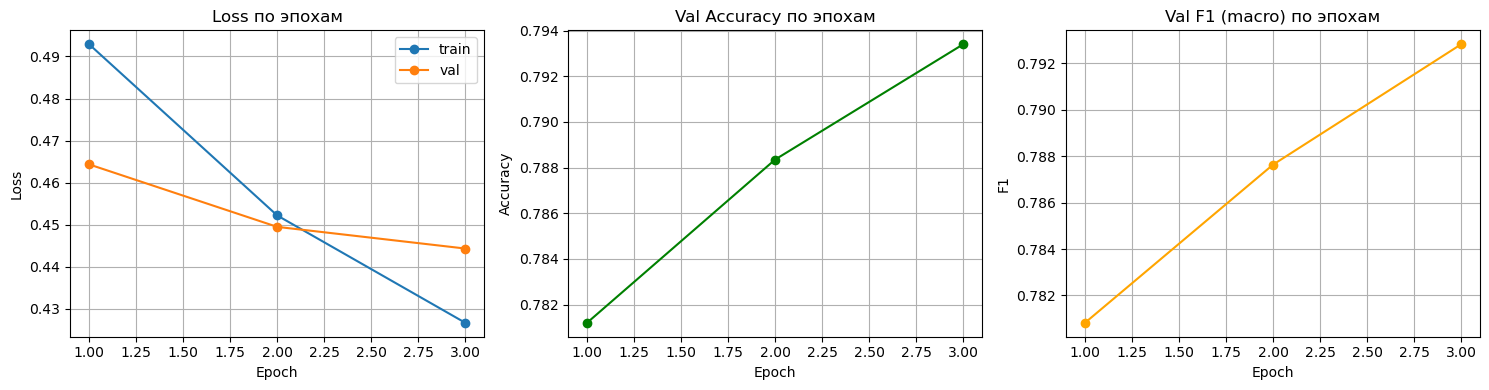

In [33]:
epochs     = [h['epoch']     for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss   = [h['val_loss']   for h in history]
val_acc    = [h['val_acc']    for h in history]
val_f1     = [h['val_f1']     for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs, train_loss, label='train', marker='o')
axes[0].plot(epochs, val_loss,   label='val',   marker='o')
axes[0].set_title('Loss по эпохам')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, val_acc, color='green', marker='o')
axes[1].set_title('Val Accuracy по эпохам')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)

# F1
axes[2].plot(epochs, val_f1, color='orange', marker='o')
axes[2].set_title('Val F1 (macro) по эпохам')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

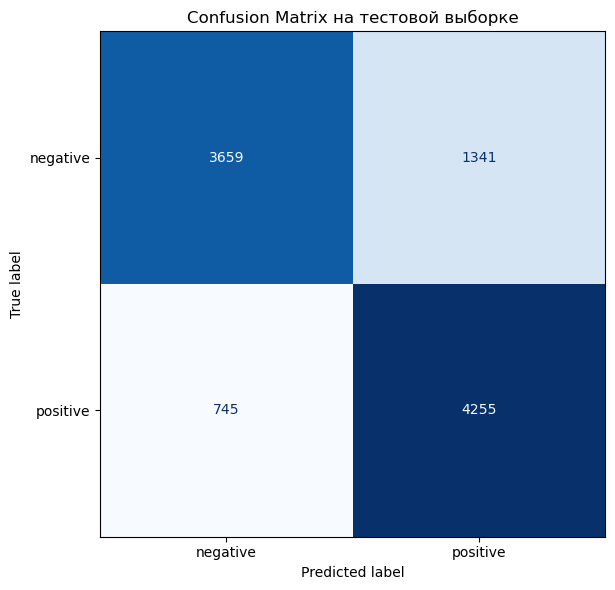

In [40]:
@torch.no_grad()
def get_all_predictions(model, loader, device):
    """Собирает все предсказания и метки для построения confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        out   = model(batch.x, batch.edge_index,batch.edge_attr ,batch.batch)
        pred  = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    return all_labels, all_preds


model.load_state_dict(torch.load(MODEL_PATH))
true_labels, pred_labels = get_all_predictions(model, test_loader, DEVICE)

cm   = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix на тестовой выборке')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
import networkx as nx
import matplotlib.pyplot as plt
import torch


def visualize_dependency_graph(text):
    if text is None or len(text.strip()) == 0:
        print("Empty text")
        return

    doc = nlp(text)

    # ограничим размер для визуализации
    doc = list(doc)
    n = len(doc)

    if n == 0:
        return

    # ===== build graph (как в build_graph) =====
    G = nx.DiGraph()

    for i, token in enumerate(doc):
        G.add_node(i, label=token.text, pos=token.pos_)

    # dependency edges
    for token in doc:
        for child in token.children:
            if child.i >= n or token.i >= n:
                continue
            G.add_edge(token.i, child.i)

    # ===== layout =====
    pos = nx.spring_layout(G, seed=42)

    labels = {i: doc[i].text for i in range(n)}

    # ===== node colors by POS =====
    def get_color(tok):
        if tok.pos_ in ["VERB"]:
            return "#FF6B6B"
        elif tok.pos_ in ["NOUN", "PROPN"]:
            return "#4ECDC4"
        elif tok.pos_ in ["ADJ"]:
            return "#FFD166"
        else:
            return "#A0A0A0"

    colors = [get_color(doc[i]) for i in range(n)]

    # ===== plot =====
    fig, ax = plt.subplots(figsize=(12, 7))

    nx.draw_networkx_nodes(
        G, pos,
        node_color=colors,
        node_size=900,
        ax=ax
    )

    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        alpha=0.4,
        edge_color="gray",
        ax=ax
    )

    nx.draw_networkx_labels(
        G, pos,
        labels=labels,
        font_size=10,
        font_weight="bold",
        ax=ax
    )

    # legend
    from matplotlib.patches import Patch
    legend = [
        Patch(color="#FF6B6B", label="VERB"),
        Patch(color="#4ECDC4", label="NOUN / PROPN"),
        Patch(color="#FFD166", label="ADJ"),
        Patch(color="#A0A0A0", label="OTHER"),
    ]
    ax.legend(handles=legend, loc="upper right")

    ax.set_title(f"Dependency Graph: \"{text[:60]}...\"" if len(text) > 60 else f"Dependency Graph: \"{text}\"")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Nodes: {n} | Edges: {G.number_of_edges()}")
    print([tok.text for tok in doc])

────────────────────────────────────────────────────────────


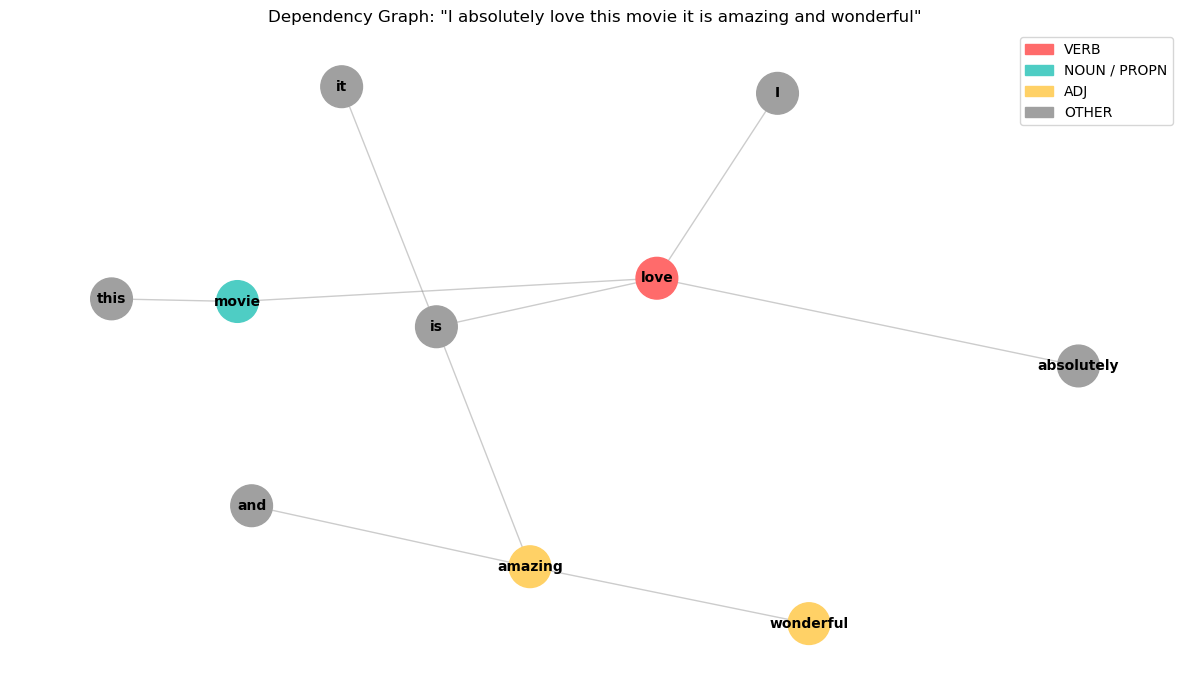

Nodes: 10 | Edges: 9
['I', 'absolutely', 'love', 'this', 'movie', 'it', 'is', 'amazing', 'and', 'wonderful']
────────────────────────────────────────────────────────────


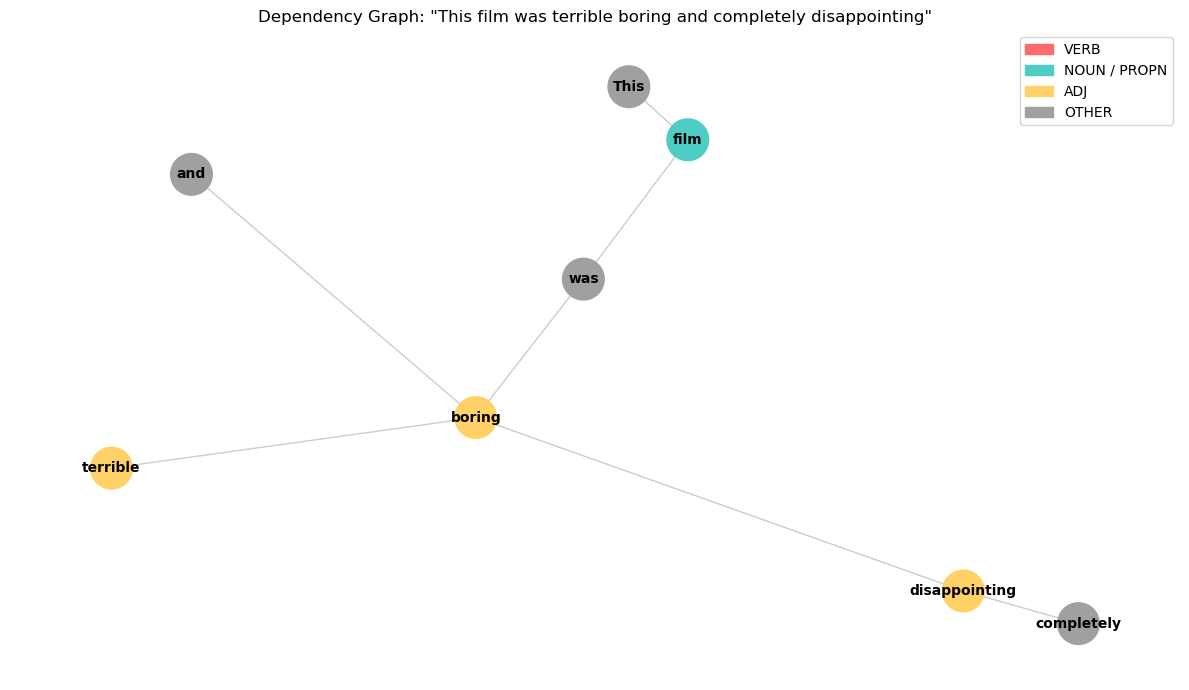

Nodes: 8 | Edges: 7
['This', 'film', 'was', 'terrible', 'boring', 'and', 'completely', 'disappointing']
────────────────────────────────────────────────────────────


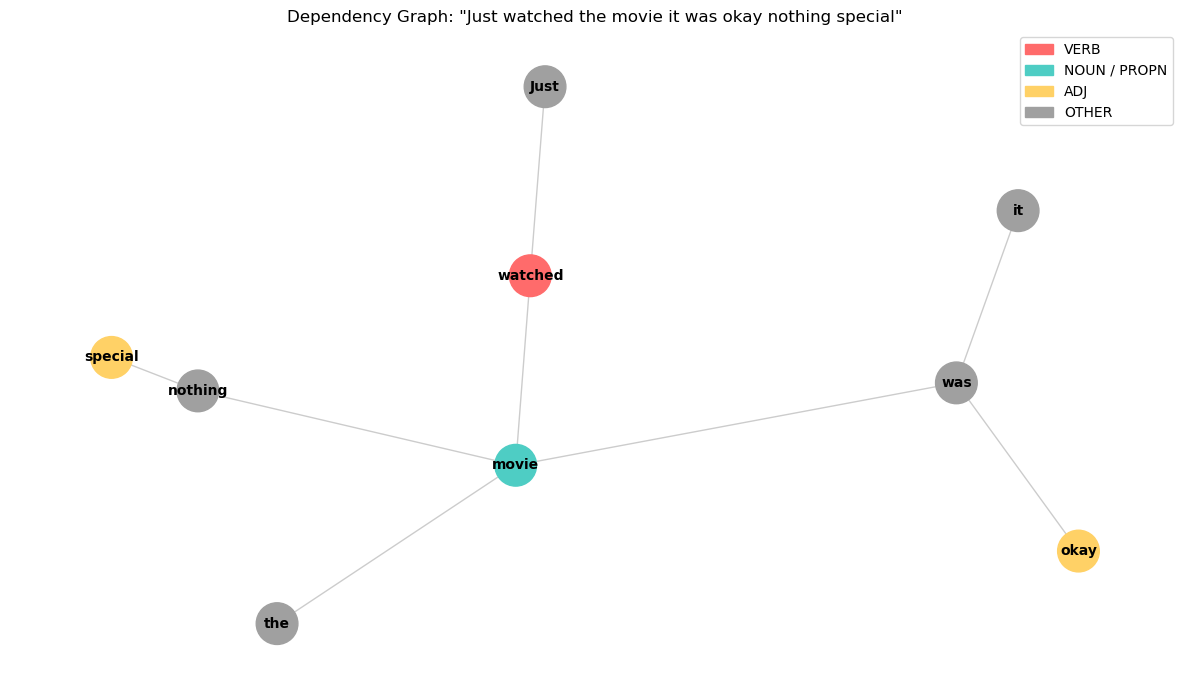

Nodes: 9 | Edges: 8
['Just', 'watched', 'the', 'movie', 'it', 'was', 'okay', 'nothing', 'special']
────────────────────────────────────────────────────────────


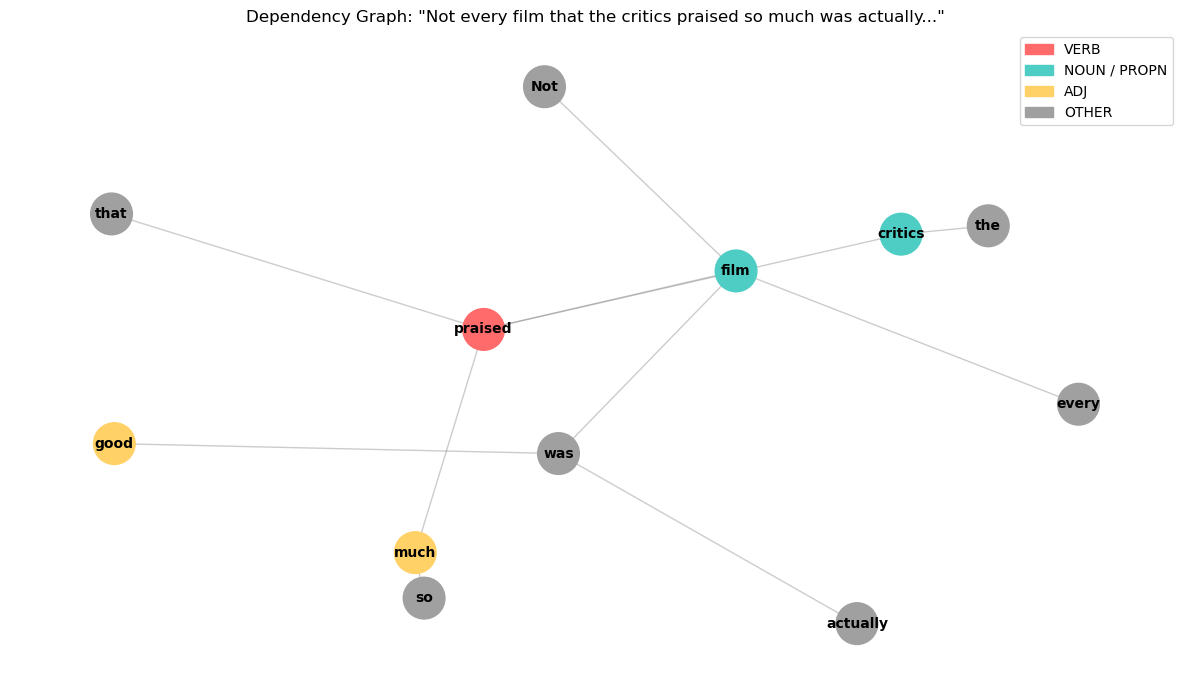

Nodes: 12 | Edges: 11
['Not', 'every', 'film', 'that', 'the', 'critics', 'praised', 'so', 'much', 'was', 'actually', 'good']


In [38]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

examples = [
    'I absolutely love this movie it is amazing and wonderful',
    'This film was terrible boring and completely disappointing',
    'Just watched the movie it was okay nothing special',
    'Not every film that the critics praised so much was actually good',
]

for text in examples:
    print('─' * 60)
    visualize_dependency_graph(text)

In [ ]:
def predict(text: str, model, tokenizer, bert_model, window: int = 2):
    model.eval()
    bert_model.eval()

    clean = preprocess(text)

    doc = nlp(clean)

    enc = tokenizer(
        clean,
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    ).to(DEVICE)

    with torch.no_grad():
        out = bert_model(**enc)

    x    = out.last_hidden_state.squeeze(0)
    mask = enc['attention_mask'].squeeze(0)
    x    = x[mask == 1]

    n = x.size(0)

    edges = []
    for token in doc:
        for child in token.children:T
            if token.i < n and child.i < n:
                edges.append([token.i, child.i])
                edges.append([child.i, token.i])

    edge_index = (torch.tensor(edges, dtype=torch.long).t().contiguous().to(DEVICE)
                  if edges else torch.zeros(2, 0, dtype=torch.long).to(DEVICE))

    batch = torch.zeros(n, dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        logits = model(x, edge_index, batch)
        probs  = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        pred   = int(probs.argmax())

    prob_dict = {LABEL_MAP[i]: float(f'{p:.3f}') for i, p in enumerate(probs)}
    return LABEL_MAP[pred], prob_dict